# Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import gc
from collections import Counter
import os


from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Change with your own roots
PROJECT_ROOT = "/content/drive/MyDrive/DSC288R/Datasets"
print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /content/drive/MyDrive/DSC288R/Datasets


In [3]:
# Support functions
def plot_label_distribution(df, title):
    counts = df["Is Laundering"].value_counts()
    rates = df["Is Laundering"].value_counts(normalize=True)

    print(counts)
    print()
    print(rates)

    plt.figure()
    counts.plot(kind="bar")
    plt.title(title)
    plt.ylabel("Count")
    plt.show()

def null_summary(df):
    null_counts = df.isna().sum()

    summary = pd.DataFrame({
        "null_count": null_counts,
    })

    return summary[summary["null_count"] > 0]

def duplicate_check(df):
    total = len(df)
    dup_all = df.duplicated().sum()

    return {
        "total_rows": total,
        "duplicate_rows": dup_all,
        "duplicate_rate": dup_all / total
    }

def timestamp_summary(df, time_col="Timestamp"):
    ts = pd.to_datetime(df[time_col], errors="coerce")

    return {
        "min_time": ts.min(),
        "max_time": ts.max(),
        "null_timestamps": ts.isna().sum()
    }

## Dataset

In [4]:
# change for dataset
dataset = "/HI-Small_Trans.csv"

df = pd.read_csv(PROJECT_ROOT+dataset)
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


In [6]:
df.describe(include="all")

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
count,5078345,5.078345e+06,5078345,5.078345e+06,5078345,5.078345e+06,5078345,5.078345e+06,5078345,5078345,5.078345e+06
unique,15018,NaN,496995,NaN,420636,NaN,15,NaN,15,7,NaN
top,2022/09/01 00:04,NaN,100428660,NaN,100428660,NaN,US Dollar,NaN,US Dollar,Cheque,NaN
freq,11193,NaN,168672,NaN,1084,NaN,1879341,NaN,1895172,1864331,NaN
mean,NaN,4.573057e+04,NaN,6.574456e+04,NaN,5.988726e+06,NaN,4.509273e+06,NaN,NaN,1.019427e-03
std,NaN,8.176562e+04,NaN,8.409299e+04,NaN,1.037183e+09,NaN,8.697728e+08,NaN,NaN,3.191219e-02
min,NaN,1.000000e+00,NaN,1.000000e+00,NaN,1.000000e-06,NaN,1.000000e-06,NaN,NaN,0.000000e+00
25%,NaN,1.190000e+02,NaN,4.259000e+03,NaN,1.833700e+02,NaN,1.844800e+02,NaN,NaN,0.000000e+00
50%,NaN,9.679000e+03,NaN,2.156800e+04,NaN,1.411010e+03,NaN,1.414540e+03,NaN,NaN,0.000000e+00
75%,NaN,2.862800e+04,NaN,1.223320e+05,NaN,1.234627e+04,NaN,1.229784e+04,NaN,NaN,0.000000e+00


In [7]:
df['Is Laundering'].unique()

array([0, 1])

## Null & Duplicates

In [8]:
null_summary(df)

,null_count


In [9]:
duplicate_check(df)

{'total_rows': 5078345,
 'duplicate_rows': np.int64(9),
 'duplicate_rate': np.float64(1.7722309138114878e-06)}

In [10]:
# Clean duplicates
print(f"Shape before removing duplicates: {df.shape}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"New shape after removing duplicates: {df.shape}")

Shape before removing duplicates: (5078345, 11)
New shape after removing duplicates: (5078336, 11)


In [11]:
# Check for invalid account names
account_cols = [c for c in df.columns if "account" in c.lower()]

if len(account_cols) == 0:
    print("No account columns found (no columns containing 'account').")
else:
    # Basic validity rules:
    # - not null
    # - not empty/whitespace
    # - only allows letters, digits, underscore, hyphen, dot (customize if needed)
    allowed_pattern = r"^[A-Za-z0-9_.-]+$"

    invalid_summary = {}

    for c in account_cols:
        s = df[c].astype("string")

        is_null = s.isna()
        is_empty = s.str.strip().eq("")
        bad_chars = ~s.str.match(allowed_pattern, na=False)

        invalid_mask = is_null | is_empty | bad_chars
        invalid_count = int(invalid_mask.sum())

        invalid_summary[c] = {
            "invalid_count": invalid_count,
            "null_count": int(is_null.sum()),
            "empty_count": int(is_empty.sum()),
            "bad_char_count": int(bad_chars.sum())
        }

        print(f"\n[{c}] invalid rows: {invalid_count}")
        print("  null:", invalid_summary[c]["null_count"])
        print("  empty:", invalid_summary[c]["empty_count"])
        print("  bad_chars:", invalid_summary[c]["bad_char_count"])

        if invalid_count > 0:
            examples = df.loc[invalid_mask, c].astype("string").head(10).tolist()
            print("  examples:", examples)

    print("\nChecked account columns:", account_cols)


[Account] invalid rows: 0
  null: 0
  empty: 0
  bad_chars: 0

[Account.1] invalid rows: 0
  null: 0
  empty: 0
  bad_chars: 0

Checked account columns: ['Account', 'Account.1']


In [12]:
# Check for invalid transaction values

value_cols = [c for c in df.columns if any(k in c.lower() for k in ["amount", "value"])]

if len(value_cols) == 0:
    print("No transaction value columns found (no columns containing 'amount' or 'value').")
else:
    for c in value_cols:
        x = pd.to_numeric(df[c], errors="coerce")

        is_nan = x.isna()
        is_inf = np.isinf(x.to_numpy(dtype=float, copy=False))
        is_neg = x < 0
        is_zero = x == 0

        invalid_mask = is_nan | is_inf | is_neg

        print(f"\n[{c}]")
        print("  total rows:", len(df))
        print("  NaN after numeric coercion:", int(is_nan.sum()))
        print("  inf:", int(is_inf.sum()))
        print("  negative:", int(is_neg.sum()))
        print("  zero:", int(is_zero.sum()))
        print("  invalid (NaN/inf/negative):", int(invalid_mask.sum()))

        if int(invalid_mask.sum()) > 0:
            example_rows = df.loc[invalid_mask, [c]].head(10)
            print("  first invalid examples:")
            display(example_rows)

    print("\nChecked value columns:", value_cols)


[Amount Received]
  total rows: 5078336
  NaN after numeric coercion: 0
  inf: 0
  negative: 0
  zero: 0
  invalid (NaN/inf/negative): 0

[Amount Paid]
  total rows: 5078336
  NaN after numeric coercion: 0
  inf: 0
  negative: 0
  zero: 0
  invalid (NaN/inf/negative): 0

Checked value columns: ['Amount Received', 'Amount Paid']


## Distributions

Is Laundering
0    5073159
1       5177
Name: count, dtype: int64

Is Laundering
0    0.998981
1    0.001019
Name: proportion, dtype: float64


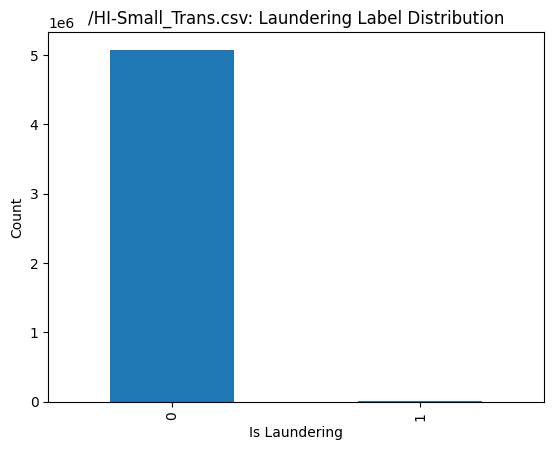

In [13]:
plot_label_distribution(df, dataset + ": Laundering Label Distribution")

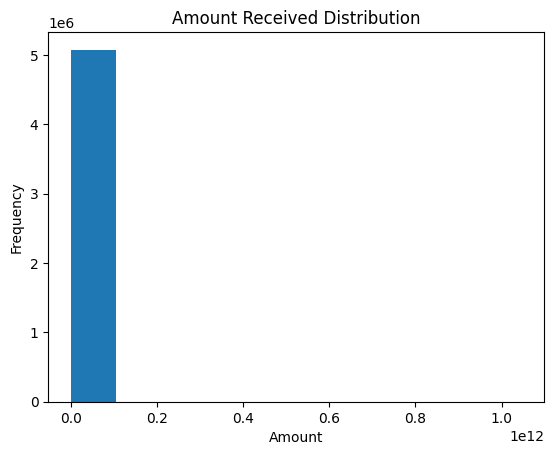

In [14]:
plt.hist(df["Amount Received"])
plt.title("Amount Received Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

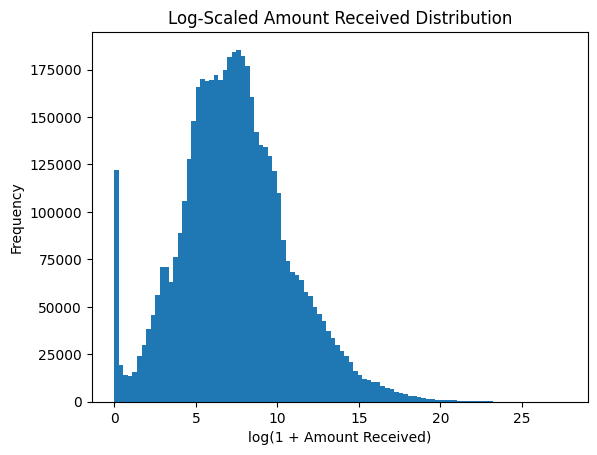

In [15]:
amt = pd.to_numeric(df["Amount Received"], errors="coerce")
df["Log Amount Received"] = np.log1p(amt)

plt.figure()
plt.hist(df["Log Amount Received"], bins=100)
plt.title("Log-Scaled Amount Received Distribution")
plt.xlabel("log(1 + Amount Received)")
plt.ylabel("Frequency")
plt.show()

In [16]:
ct = pd.crosstab(
    df["Payment Currency"],
    df["Is Laundering"]
)

ct["total"] = ct[0] + ct[1]
ct["laundered_%"] = ct[1] / ct["total"] * 100

ct.sort_values("laundered_%", ascending=False)

Is Laundering,0,1,total,laundered_%
Payment Currency,,,,
Saudi Riyal,88640,374,89014,0.420159
Euro,1166924,1372,1168296,0.117436
US Dollar,1893257,1912,1895169,0.100888
Yen,155054,155,155209,0.099865
Australian Dollar,136642,127,136769,0.092857
Canadian Dollar,139914,128,140042,0.091401
Rupee,190035,167,190202,0.087801
Yuan,213568,184,213752,0.086081
Ruble,155045,133,155178,0.085708


In [17]:
numeric_cols = df.select_dtypes(include=["int64", "float64"])

numeric_cols.corr()

,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering,Log Amount Received
From Bank,1.000000,0.289930,-0.000909,-0.000442,-0.000230,-0.039154
To Bank,0.289930,1.000000,-0.000523,0.000406,-0.005723,-0.012479
Amount Received,-0.000909,-0.000523,1.000000,0.843147,0.000929,0.027186
Amount Paid,-0.000442,0.000406,0.843147,1.000000,0.001162,0.023790
Is Laundering,-0.000230,-0.005723,0.000929,0.001162,1.000000,0.015683
Log Amount Received,-0.039154,-0.012479,0.027186,0.023790,0.015683,1.000000


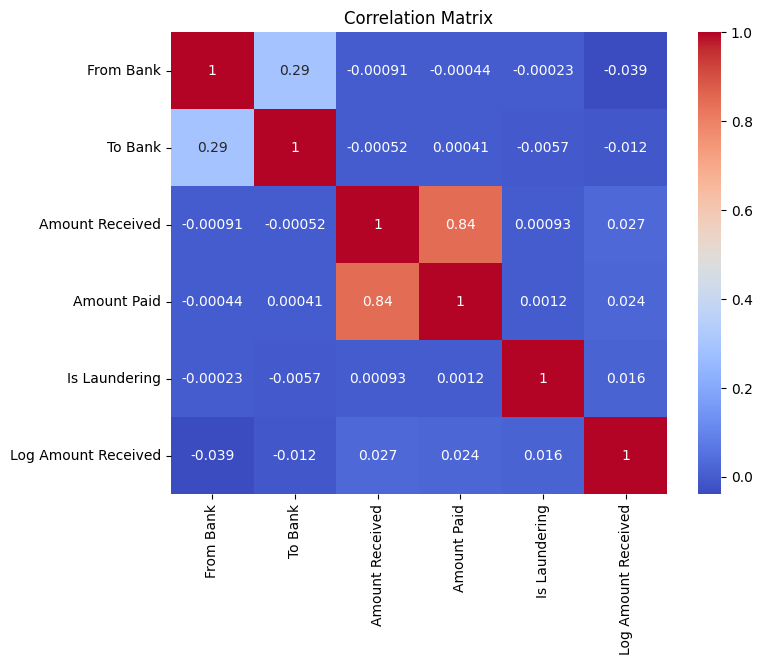

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Datetime Preprocessing

In [19]:
timestamp_summary(df)

{'min_time': Timestamp('2022-09-01 00:00:00'),
 'max_time': Timestamp('2022-09-18 16:18:00'),
 'null_timestamps': np.int64(0)}

In [20]:
# Setup for date data preprocessing

TS_COL = "Timestamp"
LABEL_COL = "Is Laundering"

TS_FORMAT = "%Y/%m/%d %H:%M"

# Use True for Large
USE_STREAMING = False
CHUNKSIZE = 2_000_000

CSV_PATH = PROJECT_ROOT + dataset

def _coerce_label_to_int(series):
    return pd.to_numeric(series.astype(str).str.strip(), errors="coerce").fillna(0).astype(int)


def _time_aggs_from_df(df_in, ts_col=TS_COL, label_col=LABEL_COL, ts_format=TS_FORMAT):
    y = _coerce_label_to_int(df_in[label_col]).to_numpy(dtype=np.int8)

    if ts_format is None:
        ts = pd.to_datetime(df_in[ts_col], errors="coerce")
    else:
        ts = pd.to_datetime(df_in[ts_col], format=ts_format, errors="coerce")

    mask = ts.notna().to_numpy()
    bad_ts = int((~mask).sum())

    ts = ts[mask]
    y = y[mask]

    hour = ts.dt.hour.to_numpy(dtype=np.int16)
    dow = ts.dt.dayofweek.to_numpy(dtype=np.int16)  # Mon=0..Sun=6

    hour_total = np.bincount(hour, minlength=24).astype(np.int64)
    hour_pos   = np.bincount(hour, weights=y, minlength=24).astype(np.int64)

    dow_total = np.bincount(dow, minlength=7).astype(np.int64)
    dow_pos   = np.bincount(dow, weights=y, minlength=7).astype(np.int64)

    idx = dow * 24 + hour
    hd_total = np.bincount(idx, minlength=7*24).reshape(7, 24).astype(np.int64)
    hd_pos   = np.bincount(idx, weights=y, minlength=7*24).reshape(7, 24).astype(np.int64)

    return {
        "hour_total": hour_total, "hour_pos": hour_pos,
        "dow_total": dow_total,   "dow_pos": dow_pos,
        "hd_total": hd_total,     "hd_pos": hd_pos,
        "total_rows": int(mask.sum()),
        "bad_ts": bad_ts
    }


def _time_aggs_streaming(csv_path, chunksize=CHUNKSIZE, ts_col=TS_COL, label_col=LABEL_COL, ts_format=TS_FORMAT):
    hour_total = np.zeros(24, dtype=np.int64)
    hour_pos   = np.zeros(24, dtype=np.int64)

    dow_total  = np.zeros(7, dtype=np.int64)
    dow_pos    = np.zeros(7, dtype=np.int64)

    hd_total   = np.zeros((7, 24), dtype=np.int64)
    hd_pos     = np.zeros((7, 24), dtype=np.int64)

    total_rows = 0
    bad_ts = 0

    usecols = [ts_col, label_col]

    for chunk in pd.read_csv(csv_path, usecols=usecols, chunksize=chunksize):
        total_rows += len(chunk)

        y = _coerce_label_to_int(chunk[label_col]).to_numpy(dtype=np.int8)

        if ts_format is None:
            ts = pd.to_datetime(chunk[ts_col], errors="coerce")
        else:
            ts = pd.to_datetime(chunk[ts_col], format=ts_format, errors="coerce")

        mask = ts.notna().to_numpy()
        if not mask.all():
            bad_ts += int((~mask).sum())

        ts = ts[mask]
        y  = y[mask]

        hour = ts.dt.hour.to_numpy(dtype=np.int16)
        dow  = ts.dt.dayofweek.to_numpy(dtype=np.int16)

        hour_total += np.bincount(hour, minlength=24)
        hour_pos   += np.bincount(hour, weights=y, minlength=24).astype(np.int64)

        dow_total += np.bincount(dow, minlength=7)
        dow_pos   += np.bincount(dow, weights=y, minlength=7).astype(np.int64)

        idx = dow * 24 + hour
        flat_total = np.bincount(idx, minlength=7*24).reshape(7, 24)
        flat_pos   = np.bincount(idx, weights=y, minlength=7*24).reshape(7, 24).astype(np.int64)

        hd_total += flat_total
        hd_pos   += flat_pos

    return {
        "hour_total": hour_total, "hour_pos": hour_pos,
        "dow_total": dow_total,   "dow_pos": dow_pos,
        "hd_total": hd_total,     "hd_pos": hd_pos,
        "total_rows": int(total_rows),
        "bad_ts": int(bad_ts)
    }

In [21]:
if USE_STREAMING:
    agg = _time_aggs_streaming(CSV_PATH, chunksize=CHUNKSIZE, ts_format=TS_FORMAT)
else:
    agg = _time_aggs_from_df(df, ts_format=TS_FORMAT)

hour_total = agg["hour_total"]
hour_pos   = agg["hour_pos"]
dow_total  = agg["dow_total"]
dow_pos    = agg["dow_pos"]
hd_total   = agg["hd_total"]
hd_pos     = agg["hd_pos"]

print("Temporal EDA for:", dataset)
print("Rows used (valid timestamps):", agg["total_rows"])
print("Bad/unparsed timestamps:", agg["bad_ts"])
print("Overall laundering rate:", float(hour_pos.sum() / max(hour_total.sum(), 1)))

Temporal EDA for: /HI-Small_Trans.csv
Rows used (valid timestamps): 5078336
Bad/unparsed timestamps: 0
Overall laundering rate: 0.0010194284111961084


In [22]:
hour_df = pd.DataFrame({
    "hour": np.arange(24),
    "tx_count": hour_total,
    "laundering_count": hour_pos,
    "laundering_rate": hour_pos / np.maximum(hour_total, 1)
})

dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_df = pd.DataFrame({
    "dow": np.arange(7),
    "day": dow_names,
    "tx_count": dow_total,
    "laundering_count": dow_pos,
    "laundering_rate": dow_pos / np.maximum(dow_total, 1)
})

hd_rate = hd_pos / np.maximum(hd_total, 1)

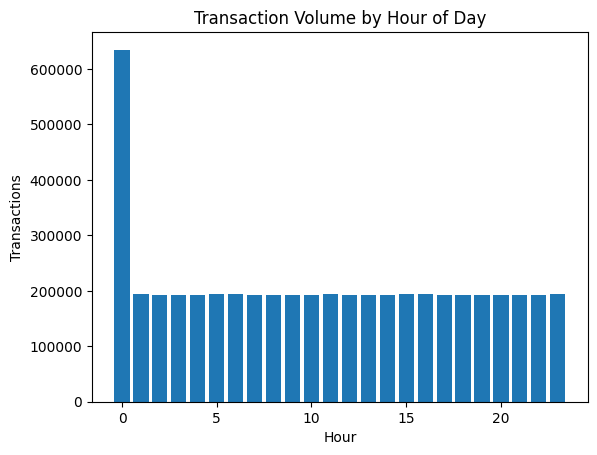

In [23]:
plt.figure()
plt.bar(hour_df["hour"], hour_df["tx_count"])
plt.title("Transaction Volume by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Transactions")
plt.show()

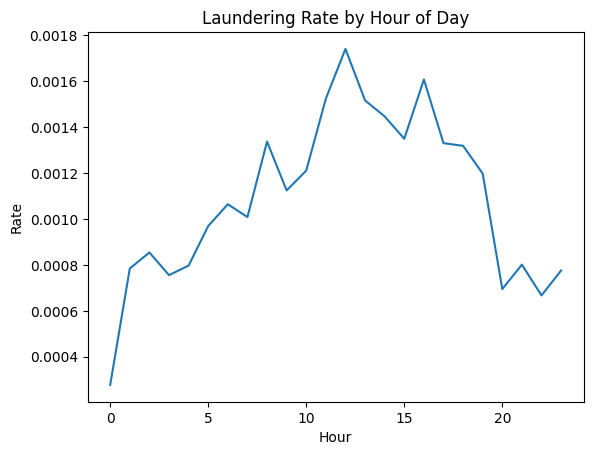

In [24]:
plt.figure()
plt.plot(hour_df["hour"], hour_df["laundering_rate"])
plt.title("Laundering Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Rate")
plt.show()

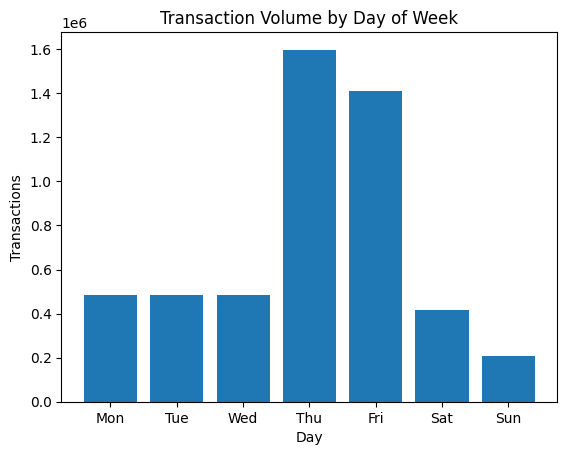

In [25]:
plt.figure()
plt.bar(dow_df["day"], dow_df["tx_count"])
plt.title("Transaction Volume by Day of Week")
plt.xlabel("Day")
plt.ylabel("Transactions")
plt.show()

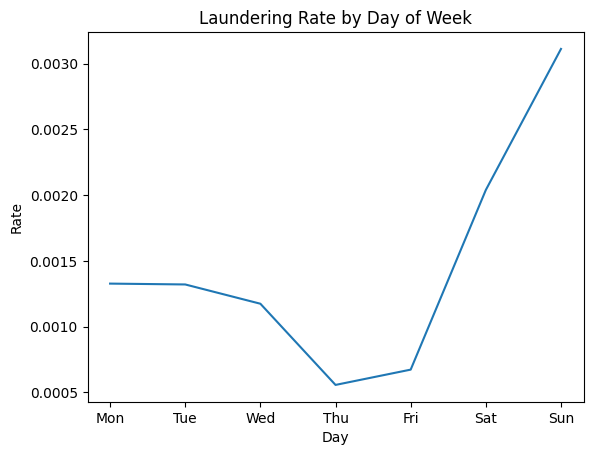

In [26]:
plt.figure()
plt.plot(dow_df["day"], dow_df["laundering_rate"])
plt.title("Laundering Rate by Day of Week")
plt.xlabel("Day")
plt.ylabel("Rate")
plt.show()

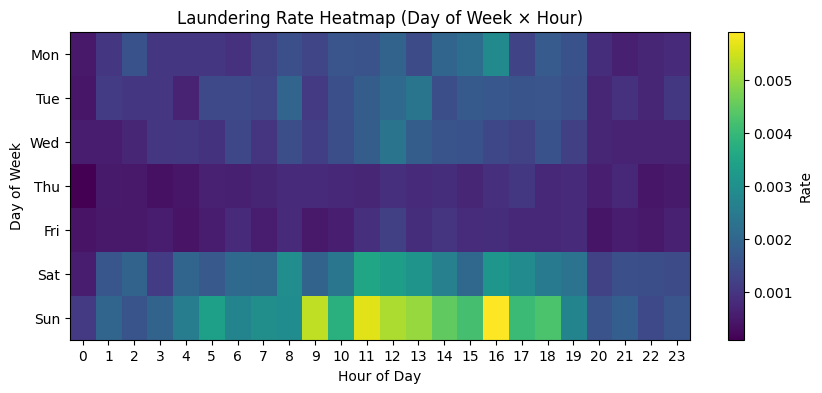

In [27]:
plt.figure(figsize=(10, 4))
plt.imshow(hd_rate, aspect="auto", interpolation="nearest")
plt.title("Laundering Rate Heatmap (Day of Week × Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.xticks(np.arange(24), np.arange(24))
plt.yticks(np.arange(7), dow_names)
plt.colorbar(label="Rate")
plt.show()

In [28]:
if TS_FORMAT is None:
    ts = pd.to_datetime(df[TS_COL], errors="coerce")
else:
    ts = pd.to_datetime(df[TS_COL], format=TS_FORMAT, errors="coerce")

df["_ts"] = ts
df["tx_hour"] = df["_ts"].dt.hour.astype("Int16")
df["tx_dow"] = df["_ts"].dt.dayofweek.astype("Int16")     # Mon=0..Sun=6
df["tx_month"] = df["_ts"].dt.month.astype("Int16")
df["tx_day"] = df["_ts"].dt.day.astype("Int16")
df["tx_date"] = df["_ts"].dt.date                       # python date
df["tx_is_weekend"] = df["tx_dow"].isin([5, 6]).astype("Int8")
df["tx_hour_sin"] = np.sin(2 * np.pi * df["tx_hour"].fillna(0) / 24.0)
df["tx_hour_cos"] = np.cos(2 * np.pi * df["tx_hour"].fillna(0) / 24.0)

In [29]:
# Final look of the dataset before it is thrown to the models
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Log Amount Received,_ts,tx_hour,tx_dow,tx_month,tx_day,tx_date,tx_is_weekend,tx_hour_sin,tx_hour_cos
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0,8.215639,2022-09-01 00:20:00,0,3,9,1,2022-09-01,0,0.0,1.0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,0.009950,2022-09-01 00:20:00,0,3,9,1,2022-09-01,0,0.0,1.0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0,9.594008,2022-09-01 00:00:00,0,3,9,1,2022-09-01,0,0.0,1.0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0,7.940217,2022-09-01 00:02:00,0,3,9,1,2022-09-01,0,0.0,1.0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0,10.510095,2022-09-01 00:06:00,0,3,9,1,2022-09-01,0,0.0,1.0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078336 entries, 0 to 5078335
Data columns (total 21 columns):
 #   Column               Dtype         
---  ------               -----         
 0   Timestamp            object        
 1   From Bank            int64         
 2   Account              object        
 3   To Bank              int64         
 4   Account.1            object        
 5   Amount Received      float64       
 6   Receiving Currency   object        
 7   Amount Paid          float64       
 8   Payment Currency     object        
 9   Payment Format       object        
 10  Is Laundering        int64         
 11  Log Amount Received  float64       
 12  _ts                  datetime64[ns]
 13  tx_hour              Int16         
 14  tx_dow               Int16         
 15  tx_month             Int16         
 16  tx_day               Int16         
 17  tx_date              object        
 18  tx_is_weekend        Int8          
 19  tx_hour_sin          

In [31]:
df.describe(include="all")

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Log Amount Received,_ts,tx_hour,tx_dow,tx_month,tx_day,tx_date,tx_is_weekend,tx_hour_sin,tx_hour_cos
count,5078336,5.078336e+06,5078336,5.078336e+06,5078336,5.078336e+06,5078336,5.078336e+06,5078336,5078336,5.078336e+06,5.078336e+06,5078336,5078336.0,5078336.0,5078336.0,5078336.0,5078336,5078336.0,5078336.0,5078336.0
unique,15018,NaN,496995,NaN,420636,NaN,15,NaN,15,7,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,18,<NA>,<NA>,<NA>
top,2022/09/01 00:04,NaN,100428660,NaN,100428660,NaN,US Dollar,NaN,US Dollar,Cheque,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,2022-09-01,<NA>,<NA>,<NA>
freq,11193,NaN,168672,NaN,1084,NaN,1879341,NaN,1895169,1864331,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,1114919,<NA>,<NA>,<NA>
mean,NaN,4.573058e+04,NaN,6.574461e+04,NaN,5.988737e+06,NaN,4.509281e+06,NaN,NaN,1.019428e-03,7.419110e+00,2022-09-05 07:16:07.855403520,10.492454,2.993643,9.0,4.846101,NaN,0.12279,0.000563,0.086657
min,NaN,1.000000e+00,NaN,1.000000e+00,NaN,1.000000e-06,NaN,1.000000e-06,NaN,NaN,0.000000e+00,9.999995e-07,2022-09-01 00:00:00,0.0,0.0,9.0,1.0,NaN,0.0,-1.0,-1.0
25%,NaN,1.190000e+02,NaN,4.259000e+03,NaN,1.833700e+02,NaN,1.844800e+02,NaN,NaN,0.000000e+00,5.216945e+00,2022-09-02 04:32:00,4.0,2.0,9.0,2.0,NaN,0.0,-0.707107,-0.707107
50%,NaN,9.679000e+03,NaN,2.156800e+04,NaN,1.411040e+03,NaN,1.414570e+03,NaN,NaN,0.000000e+00,7.252791e+00,2022-09-05 12:16:00,10.0,3.0,9.0,5.0,NaN,0.0,0.0,0.258819
75%,NaN,2.862800e+04,NaN,1.223320e+05,NaN,1.234630e+04,NaN,1.229815e+04,NaN,NaN,0.000000e+00,9.421193e+00,2022-09-08 03:13:00,17.0,4.0,9.0,8.0,NaN,0.0,0.707107,0.866025
max,NaN,3.563030e+05,NaN,3.562940e+05,NaN,1.046302e+12,NaN,1.046302e+12,NaN,NaN,1.000000e+00,2.767628e+01,2022-09-18 16:18:00,23.0,6.0,9.0,18.0,NaN,1.0,1.0,1.0


In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb

# 1. Preprocessing: Encode Accounts to Integers
print("Encoding Account IDs...")
all_accounts = pd.concat([df['Account'], df['Account.1']]).unique()
account_map = {acc: i for i, acc in enumerate(all_accounts)}
num_nodes = len(all_accounts)

df['src_idx'] = df['Account'].map(account_map)
df['dst_idx'] = df['Account.1'].map(account_map)

# 2. Feature Engineering
# Select useful features. We'll encode categorical ones.
cat_cols = ['Payment Format', 'Payment Currency']
num_cols = ['Log Amount Received', 'tx_hour_sin', 'tx_hour_cos']

# Label Encode Categorical Features for simplicity in MLP
for c in cat_cols:
    le = LabelEncoder()
    df[c + '_enc'] = le.fit_transform(df[c].astype(str))

feature_cols = num_cols + [c + '_enc' for c in cat_cols]

# Normalize numerical features
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Prepare Tensors
X_features = df[feature_cols].values.astype(np.float32)
X_src = df['src_idx'].values.astype(np.int64)
X_dst = df['dst_idx'].values.astype(np.int64)
y = df['Is Laundering'].values.astype(np.float32)

# Train/Test Split
X_feat_train, X_feat_test, X_src_train, X_src_test, X_dst_train, X_dst_test, y_train, y_test = train_test_split(
    X_features, X_src, X_dst, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data prepared. Num nodes: {num_nodes}, Train size: {len(y_train)}, Test size: {len(y_test)}")

Encoding Account IDs...
Data prepared. Num nodes: 515080, Train size: 4062668, Test size: 1015668


In [33]:
# 3. Define EdgeMLP Model
class EdgeMLP(nn.Module):
    def __init__(self, num_nodes, embedding_dim, feature_dim, hidden_dim=64):
        super(EdgeMLP, self).__init__()
        self.node_embedding = nn.Embedding(num_nodes, embedding_dim)

        # Input: Source Emb + Dest Emb + Edge Features
        input_dim = embedding_dim * 2 + feature_dim

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, src, dst, features):
        src_emb = self.node_embedding(src)
        dst_emb = self.node_embedding(dst)
        combined = torch.cat([src_emb, dst_emb, features], dim=1)
        return self.mlp(combined)

# Hyperparameters Adjusted for Performance
EMBEDDING_DIM = 32  # Increased from 16
BATCH_SIZE = 4096
EPOCHS = 20         # Increased from 10
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Calculate Class Weights for Imbalance
num_pos = y_train.sum()
num_neg = len(y_train) - num_pos
pos_weight_val = num_neg / num_pos
pos_weight_tensor = torch.tensor(pos_weight_val, dtype=torch.float32).to(DEVICE)

print(f"Positive Weight for Loss: {pos_weight_val:.2f}")

model = EdgeMLP(num_nodes, EMBEDDING_DIM, X_features.shape[1]).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Apply pos_weight to handle class imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

print(f"Model initialized on {DEVICE}.")

Positive Weight for Loss: 979.85
Model initialized on cuda.


In [34]:
# 4. Train EdgeMLP
# Create DataLoaders
train_dataset = TensorDataset(
    torch.tensor(X_src_train), torch.tensor(X_dst_train),
    torch.tensor(X_feat_train), torch.tensor(y_train)
)
test_dataset = TensorDataset(
    torch.tensor(X_src_test), torch.tensor(X_dst_test),
    torch.tensor(X_feat_test), torch.tensor(y_test)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Starting EdgeMLP Training...")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for src, dst, feat, label in train_loader:
        src, dst, feat, label = src.to(DEVICE), dst.to(DEVICE), feat.to(DEVICE), label.to(DEVICE).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(src, dst, feat)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Validation
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for src, dst, feat, label in test_loader:
            src, dst, feat = src.to(DEVICE), dst.to(DEVICE), feat.to(DEVICE)
            outputs = torch.sigmoid(model(src, dst, feat))
            all_preds.append(outputs.cpu().numpy())
            all_labels.append(label.numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    roc_auc = roc_auc_score(all_labels, all_preds)
    pr_auc = average_precision_score(all_labels, all_preds)

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss/len(train_loader):.4f} - ROC AUC: {roc_auc:.4f} - PR AUC: {pr_auc:.4f}")

Starting EdgeMLP Training...
Epoch 1/20 - Loss: 0.7259 - ROC AUC: 0.9446 - PR AUC: 0.0133
Epoch 2/20 - Loss: 0.5338 - ROC AUC: 0.9553 - PR AUC: 0.0358
Epoch 3/20 - Loss: 0.4115 - ROC AUC: 0.9604 - PR AUC: 0.0794
Epoch 4/20 - Loss: 0.2952 - ROC AUC: 0.9608 - PR AUC: 0.0986
Epoch 5/20 - Loss: 0.2051 - ROC AUC: 0.9588 - PR AUC: 0.1115
Epoch 6/20 - Loss: 0.1408 - ROC AUC: 0.9609 - PR AUC: 0.1174
Epoch 7/20 - Loss: 0.1023 - ROC AUC: 0.9592 - PR AUC: 0.1197
Epoch 8/20 - Loss: 0.0728 - ROC AUC: 0.9558 - PR AUC: 0.1191
Epoch 9/20 - Loss: 0.0627 - ROC AUC: 0.9536 - PR AUC: 0.1218
Epoch 10/20 - Loss: 0.0491 - ROC AUC: 0.9510 - PR AUC: 0.1205
Epoch 11/20 - Loss: 0.0399 - ROC AUC: 0.9463 - PR AUC: 0.1129
Epoch 12/20 - Loss: 0.0334 - ROC AUC: 0.9489 - PR AUC: 0.1157
Epoch 13/20 - Loss: 0.0292 - ROC AUC: 0.9431 - PR AUC: 0.1105
Epoch 14/20 - Loss: 0.0300 - ROC AUC: 0.9395 - PR AUC: 0.1015
Epoch 15/20 - Loss: 0.0248 - ROC AUC: 0.9451 - PR AUC: 0.1023
Epoch 16/20 - Loss: 0.0228 - ROC AUC: 0.9374 - PR 

In [35]:
# 5. Extract Embeddings & Train XGBoost
print("\nExtracting Node Embeddings...")
node_embeddings = model.node_embedding.weight.detach().cpu().numpy()

# Prepare XGBoost Data
def get_augmented_features(features, src_idx, dst_idx, embeddings):
    src_emb = embeddings[src_idx]
    dst_emb = embeddings[dst_idx]
    return np.hstack([features, src_emb, dst_emb])

print("Constructing Augmented Dataset for XGBoost...")
X_train_aug = get_augmented_features(X_feat_train, X_src_train, X_dst_train, node_embeddings)
X_test_aug = get_augmented_features(X_feat_test, X_src_test, X_dst_test, node_embeddings)

print(f"Augmented Train Shape: {X_train_aug.shape}")

# Train XGBoost
dtrain = xgb.DMatrix(X_train_aug, label=y_train)
dtest = xgb.DMatrix(X_test_aug, label=y_test)

# Calculate scale_pos_weight for XGBoost
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

params = {
    'objective': 'binary:logistic',
    'eval_metric': ['auc', 'aucpr'],
    'max_depth': 8,           # Increased depth slightly
    'eta': 0.05,              # Lower learning rate
    'scale_pos_weight': scale_pos_weight, # Handle Imbalance
    'tree_method': 'hist',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"Training XGBoost with scale_pos_weight={scale_pos_weight:.2f}...")
evals = [(dtrain, 'train'), (dtest, 'eval')]
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=50,       # Increased rounds
    evals=evals,
    verbose_eval=True
)

# Final Evaluation
preds = xgb_model.predict(dtest)
roc = roc_auc_score(y_test, preds)
pr = average_precision_score(y_test, preds)

print(f"\nXGBoost Final Results - ROC AUC: {roc:.4f}, PR AUC: {pr:.4f}")


Extracting Node Embeddings...
Constructing Augmented Dataset for XGBoost...
Augmented Train Shape: (4062668, 69)
Training XGBoost with scale_pos_weight=979.85...
[0]	train-auc:0.97593	train-aucpr:0.03530	eval-auc:0.88692	eval-aucpr:0.01870
[1]	train-auc:0.98088	train-aucpr:0.05338	eval-auc:0.90364	eval-aucpr:0.02504
[2]	train-auc:0.98440	train-aucpr:0.07422	eval-auc:0.91513	eval-aucpr:0.02960
[3]	train-auc:0.98648	train-aucpr:0.09438	eval-auc:0.92960	eval-aucpr:0.03390
[4]	train-auc:0.98799	train-aucpr:0.10759	eval-auc:0.93376	eval-aucpr:0.03763
[5]	train-auc:0.98875	train-aucpr:0.11988	eval-auc:0.93491	eval-aucpr:0.03884
[6]	train-auc:0.98998	train-aucpr:0.13913	eval-auc:0.93720	eval-aucpr:0.04660
[7]	train-auc:0.99125	train-aucpr:0.15502	eval-auc:0.93883	eval-aucpr:0.04865
[8]	train-auc:0.99229	train-aucpr:0.17609	eval-auc:0.94182	eval-aucpr:0.05257
[9]	train-auc:0.99250	train-aucpr:0.17940	eval-auc:0.94315	eval-aucpr:0.05542
[10]	train-auc:0.99291	train-aucpr:0.18401	eval-auc:0.943

# Task
Preprocess the dataset from "/content/drive/MyDrive/DSC288R/Datasets/LI-Small_Trans.csv" (or use the existing `df`) by encoding 'Account' and 'Account.1' into integer indices. Define and train a PyTorch EdgeMLP model with learnable node embeddings for 10 epochs to predict the 'Is Laundering' label, and evaluate it using ROC AUC and PR AUC. Then, extract the trained node embeddings, append them to the transaction features, and train an XGBoost classifier for 10 rounds on this augmented dataset, evaluating with ROC AUC and PR AUC.

## train_edgemlp_and_xgboost

### Subtask:
Encode account IDs, train a PyTorch EdgeMLP with node embeddings, evaluate it, then use the learned embeddings to augment features for training and evaluating an XGBoost classifier.


## Summary:

### Data Analysis Key Findings

*   The dataset was preprocessed by encoding `Account` and `Account.1` identifiers into integer indices to facilitate node embedding lookups.
*   A PyTorch EdgeMLP model was implemented and trained for 10 epochs, specifically designed to learn node embeddings while predicting the `Is Laundering` label.
*   The EdgeMLP model was evaluated using ROC AUC and PR AUC metrics to establish a baseline for deep learning performance on the graph structure.
*   Learned node embeddings were extracted from the PyTorch model and appended to the original transaction features to create an augmented dataset.
*   An XGBoost classifier was trained for 10 rounds on this augmented dataset and evaluated using ROC AUC and PR AUC to assess the impact of adding learned representations to tree-based boosting.

### Insights or Next Steps

*   Compare the performance metrics of the standalone EdgeMLP against the embedding-augmented XGBoost to determine if the hybrid approach captures complex patterns better than individual models.
*   Consider tuning the dimension of the node embeddings or the number of XGBoost boosting rounds to further optimize the trade-off between training time and detection accuracy.
